In [1]:
from pathlib import Path
import json

dataset_path = Path("../../data/item_images/raw/unu")

json_files = list(dataset_path.rglob("*.json"))

for file in json_files:
    print(file)

..\..\data\item_images\raw\unu\test\_annotations.coco.json
..\..\data\item_images\raw\unu\train\_annotations.coco.json
..\..\data\item_images\raw\unu\valid\_annotations.coco.json


Count them across train/valid/test

In [2]:
target_ids = {
    39: "Laptop",
    50: "Power-Adapter",
    70: "Tablet"
}

split_counts = {}

total_image_counts = {
    "Laptop": 0,
    "Power-Adapter": 0,
    "Tablet": 0
}

total_object_counts = {
    "Laptop": 0,
    "Power-Adapter": 0,
    "Tablet": 0
}


for json_file in json_files:

    split = json_file.parent.name

    with open(json_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    image_ids_by_class = {
        name: set()
        for name in target_ids.values()
    }

    object_counts = {
        name: 0
        for name in target_ids.values()
    }


    for ann in data["annotations"]:

        category_id = ann["category_id"]

        if category_id in target_ids:

            class_name = target_ids[category_id]

            object_counts[class_name] += 1

            image_ids_by_class[
                class_name
            ].add(
                ann["image_id"]
            )


    split_counts[split] = {}


    for class_name in target_ids.values():

        image_count = len(
            image_ids_by_class[class_name]
        )

        split_counts[split][class_name] = {
            "images": image_count,
            "objects": object_counts[class_name]
        }

        total_image_counts[
            class_name
        ] += image_count

        total_object_counts[
            class_name
        ] += object_counts[class_name]


print("===== SPLIT-WISE =====")

for split, counts in split_counts.items():

    print(f"\n{split}")

    for class_name, values in counts.items():
        print(class_name, values)


print("\n===== TOTAL IMAGES =====")
print(total_image_counts)

print("\n===== TOTAL OBJECTS =====")
print(total_object_counts)

===== SPLIT-WISE =====

test
Laptop {'images': 119, 'objects': 153}
Power-Adapter {'images': 2, 'objects': 2}
Tablet {'images': 1, 'objects': 1}

train
Laptop {'images': 853, 'objects': 1026}
Power-Adapter {'images': 26, 'objects': 37}
Tablet {'images': 7, 'objects': 7}

valid
Laptop {'images': 268, 'objects': 323}
Power-Adapter {'images': 6, 'objects': 8}
Tablet {'images': 3, 'objects': 3}

===== TOTAL IMAGES =====
{'Laptop': 1240, 'Power-Adapter': 34, 'Tablet': 11}

===== TOTAL OBJECTS =====
{'Laptop': 1502, 'Power-Adapter': 47, 'Tablet': 11}


In [3]:
combined_laptop_tablet_images = set()

for json_file in json_files:

    split = json_file.parent.name

    with open(json_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    for ann in data["annotations"]:

        if ann["category_id"] in [39, 70]:

            combined_laptop_tablet_images.add(
                (split, ann["image_id"])
            )


print(
    "Distinct Laptop + Tablet images:",
    len(combined_laptop_tablet_images)
)

Distinct Laptop + Tablet images: 1248


## Class Selection Decision

For this UNU-KEY source:

- Laptop (class ID 39) → laptop_tablet
- Tablet (class ID 70) → laptop_tablet

Power-Adapter (class ID 50) was inspected only for its available count.

The number of Power-Adapter samples was considered insufficient to meaningfully complete the `charger_adapter` class, so Power-Adapter will NOT be used from UNU-KEY.

A stronger additional charger source will be selected later.

Desktop-PC is intentionally excluded from `laptop_tablet`.

UNU Laptop + Tablet EDA

Build one Laptop/Tablet dataframe

In [4]:
import pandas as pd
import json
import re
from pathlib import Path

LT_IDS = {
    39: "Laptop",
    70: "Tablet"
}


def get_source_group(file_name):

    stem = Path(file_name).stem

    # remove Roboflow hash
    base = stem.split(".rf.")[0]

    # remove original extension marker
    base = re.sub(
        r"_(jpg|jpeg|png|webp)$",
        "",
        base,
        flags=re.IGNORECASE
    )

    return base


rows = []

for json_file in json_files:

    split = json_file.parent.name

    with open(json_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    image_lookup = {
        img["id"]: img
        for img in data["images"]
    }

    for ann in data["annotations"]:

        class_id = ann["category_id"]

        if class_id not in LT_IDS:
            continue

        img = image_lookup[ann["image_id"]]

        x, y, w, h = ann["bbox"]

        rows.append({

            "split": split,

            "annotation_id":
                ann["id"],

            "image_id":
                ann["image_id"],

            "file_name":
                img["file_name"],

            "source_group_id":
                get_source_group(
                    img["file_name"]
                ),

            "original_class_id":
                class_id,

            "original_label":
                LT_IDS[class_id],

            "esafe_label":
                "laptop_tablet",

            "image_width":
                img["width"],

            "image_height":
                img["height"],

            "bbox_x":
                x,

            "bbox_y":
                y,

            "bbox_width":
                w,

            "bbox_height":
                h,

            "bbox_area_ratio":
                (w * h) /
                (img["width"] * img["height"]),

            "has_segmentation":
                bool(
                    ann.get("segmentation")
                ),

            "iscrowd":
                ann.get("iscrowd", 0)
        })


lt_df = pd.DataFrame(rows)

print(lt_df.shape)

print(
    lt_df[
        "original_label"
    ].value_counts()
)

lt_df.head()

(1513, 17)
original_label
Laptop    1502
Tablet      11
Name: count, dtype: int64


,split,annotation_id,image_id,file_name,source_group_id,original_class_id,original_label,esafe_label,image_width,image_height,bbox_x,bbox_y,bbox_width,bbox_height,bbox_area_ratio,has_segmentation,iscrowd
0,test,4,4,000000381160_jpg.rf.028674326684d50439af3b74c0...,000000381160,39,Laptop,laptop_tablet,640,640,2,109,636.582,288.371,0.448173,True,0
1,test,26,21,000000096757_jpg.rf.01febdaa039cb520c6df36840a...,000000096757,39,Laptop,laptop_tablet,640,640,297,261,342.400,291.460,0.243642,True,0
2,test,27,21,000000096757_jpg.rf.01febdaa039cb520c6df36840a...,000000096757,39,Laptop,laptop_tablet,640,640,159,350,195.430,56.920,0.027158,True,0
3,test,31,23,000000249111_jpg.rf.025f6cd960d3f718fe7767953b...,000000249111,39,Laptop,laptop_tablet,640,640,86,48,465.971,399.821,0.454846,True,0
4,test,87,41,000000518080_jpg.rf.04393a45d8424902800a1a72f7...,000000518080,39,Laptop,laptop_tablet,640,640,234,379,212.850,230.110,0.119577,True,0


Get the TRUE number of distinct images

In [5]:
target_images = (
    lt_df[
        [
            "split",
            "image_id",
            "file_name",
            "image_width",
            "image_height",
            "source_group_id"
        ]
    ]
    .drop_duplicates(
        subset=[
            "split",
            "image_id"
        ]
    )
)


print(
    "Total Laptop/Tablet objects:",
    len(lt_df)
)

print(
    "Distinct Laptop/Tablet images:",
    len(target_images)
)

Total Laptop/Tablet objects: 1513
Distinct Laptop/Tablet images: 1248


In [6]:
print(
    "\nDistinct images by original class:"
)

for label in ["Laptop", "Tablet"]:

    count = (
        lt_df[
            lt_df["original_label"] == label
        ][
            ["split", "image_id"]
        ]
        .drop_duplicates()
        .shape[0]
    )

    print(label, count)


Distinct images by original class:
Laptop 1240
Tablet 11


Check images containing BOTH laptop and tablet

In [7]:
classes_per_image = (
    lt_df
    .groupby(
        [
            "split",
            "image_id"
        ]
    )["original_label"]
    .agg(lambda x: set(x))
)


both_classes = classes_per_image[
    classes_per_image.apply(
        lambda x:
        "Laptop" in x
        and
        "Tablet" in x
    )
]


print(
    "Images containing both Laptop and Tablet:",
    len(both_classes)
)

Images containing both Laptop and Tablet: 3


Check multiple Laptop/Tablet objects in one image

In [8]:
objects_per_image = (
    lt_df
    .groupby(
        [
            "split",
            "image_id",
            "file_name"
        ]
    )
    .size()
    .sort_values(
        ascending=False
    )
)


print(
    "Images with multiple Laptop/Tablet objects:",
    (objects_per_image > 1).sum()
)

print(
    "Maximum target objects in one image:",
    objects_per_image.max()
)

print(
    "\nDistribution:"
)

print(
    objects_per_image
    .value_counts()
    .sort_index()
)

Images with multiple Laptop/Tablet objects: 190
Maximum target objects in one image: 13

Distribution:
1     1058
2      157
3       18
4        6
5        2
6        4
7        1
9        1
13       1
Name: count, dtype: int64


Validate every bounding box

In [9]:
invalid_boxes = []

for _, row in lt_df.iterrows():

    x = row["bbox_x"]
    y = row["bbox_y"]

    w = row["bbox_width"]
    h = row["bbox_height"]

    W = row["image_width"]
    H = row["image_height"]


    valid = (
        x >= 0
        and y >= 0
        and w > 0
        and h > 0
        and x + w <= W + 1
        and y + h <= H + 1
    )


    if not valid:

        invalid_boxes.append(
            row[
                [
                    "file_name",
                    "original_label",
                    "bbox_x",
                    "bbox_y",
                    "bbox_width",
                    "bbox_height"
                ]
            ].to_dict()
        )


print(
    "Invalid/out-of-bounds boxes:",
    len(invalid_boxes)
)

print(
    invalid_boxes[:10]
)

Invalid/out-of-bounds boxes: 0
[]


Check dimensions

In [10]:
print(
    target_images[
        [
            "image_width",
            "image_height"
        ]
    ]
    .value_counts()
)

image_width  image_height
640          640             1248
Name: count, dtype: int64


Missing/corrupt files

In [11]:
def find_split_image(split, file_name):

    possible_paths = [
        dataset_path / split / file_name,
        dataset_path / split / "images" / file_name
    ]

    for path in possible_paths:

        if path.exists():
            return path

    return None

In [12]:
from PIL import Image

missing_images = []
corrupt_images = []


for _, row in target_images.iterrows():

    image_path = find_split_image(
        row["split"],
        row["file_name"]
    )

    if image_path is None:

        missing_images.append(
            row["file_name"]
        )

        continue


    try:

        with Image.open(
            image_path
        ) as img:

            img.verify()

    except Exception as e:

        corrupt_images.append(
            (
                row["file_name"],
                str(e)
            )
        )


print(
    "Missing images:",
    len(missing_images)
)

print(
    "Corrupt images:",
    len(corrupt_images)
)

Missing images: 0
Corrupt images: 0


Check the duplicate/source-family problem

In [13]:
group_sizes = (
    target_images
    .groupby(
        "source_group_id"
    )
    .size()
    .sort_values(
        ascending=False
    )
)


repeated_source_groups = (
    group_sizes[
        group_sizes > 1
    ]
)


print(
    "Distinct raw images:",
    len(target_images)
)

print(
    "Unique source groups:",
    target_images[
        "source_group_id"
    ].nunique()
)

print(
    "Repeated source groups:",
    len(
        repeated_source_groups
    )
)

print(
    "\nLargest groups:"
)

print(
    repeated_source_groups.head(20)
)

Distinct raw images: 1248
Unique source groups: 1220
Repeated source groups: 27

Largest groups:
source_group_id
IMG_20200329_152704    3
abc                    2
00107c014500a8cb       2
249                    2
304                    2
313                    2
501                    2
IMG_20200329_142737    2
IMG_20200329_152649    2
IMG_20200329_152654    2
IMG_20200329_152659    2
IMG_20200329_152708    2
IMG_20200329_152720    2
IMG_20200329_152730    2
IMG_20200329_152734    2
IMG_20200329_152735    2
IMG_20200329_152741    2
IMG_20200329_152746    2
IMG_20200329_152752    2
IMG_20200329_152755    2
dtype: int64


In [14]:
print(
    "Possible repeated/related images:",
    len(target_images)
    -
    target_images[
        "source_group_id"
    ].nunique()
)

Possible repeated/related images: 28


Check split leakage

In [15]:
group_splits = (
    target_images[
        [
            "source_group_id",
            "split"
        ]
    ]
    .drop_duplicates()
    .groupby(
        "source_group_id"
    )["split"]
    .agg(
        lambda x:
        sorted(set(x))
    )
)


cross_split_groups = (
    group_splits[
        group_splits.apply(len) > 1
    ]
)


print(
    "Source groups appearing across multiple splits:",
    len(cross_split_groups)
)

print(
    cross_split_groups.head(20)
)

Source groups appearing across multiple splits: 14
source_group_id
00107c014500a8cb             [train, valid]
249                           [test, train]
313                           [test, train]
501                           [test, valid]
IMG_20200329_142737           [test, train]
IMG_20200329_152649          [train, valid]
IMG_20200329_152654          [train, valid]
IMG_20200329_152704    [test, train, valid]
IMG_20200329_152734          [train, valid]
IMG_20200329_152804          [train, valid]
IMG_20200329_152844          [train, valid]
IMG_20200329_152857          [train, valid]
IMG_20200329_152858          [train, valid]
abc                           [test, train]
Name: split, dtype: object


Exact duplicate detection

In [16]:
import hashlib
from collections import defaultdict


hash_to_files = defaultdict(list)


for _, row in target_images.iterrows():

    image_path = find_split_image(
        row["split"],
        row["file_name"]
    )

    if image_path is None:
        continue


    with open(
        image_path,
        "rb"
    ) as f:

        file_hash = hashlib.md5(
            f.read()
        ).hexdigest()


    hash_to_files[
        file_hash
    ].append(
        (
            row["split"],
            row["file_name"]
        )
    )


exact_duplicate_groups = [

    files

    for files
    in hash_to_files.values()

    if len(files) > 1
]


print(
    "Exact duplicate groups:",
    len(exact_duplicate_groups)
)


for group in exact_duplicate_groups[:10]:

    print("\n", group)

Exact duplicate groups: 23

 [('test', '313_jpeg.rf.7168de3b371bd111533d7848a0ff8b37.jpg'), ('train', '313_jpeg.rf.e8894a258f1f6350100f31767cacf1ea.jpg')]

 [('test', 'IMG_20200329_152704_jpg.rf.b5ef6b05e65f8d4a577efa1425dfb32d.jpg'), ('train', 'IMG_20200329_152704_jpg.rf.cd90ef30b595860e6fb8e253ff31e9aa.jpg')]

 [('test', '501_jpeg.rf.df204d7cf953853fa19e62a433b04d11.jpg'), ('valid', '501_jpeg.rf.98d626e93a2c621c4e8abe2193bdbfa4.jpg')]

 [('train', 'IMG_20200329_152800_jpg.rf.0272f8df7d9c7e393a7ad018f408cd67.jpg'), ('train', 'IMG_20200329_152800_jpg.rf.1d6feac3c244fc0eeceb53c8dc0fca8d.jpg')]

 [('train', 'IMG_20200329_152840-1-_jpg.rf.a1da0b0c4084996be47eeb70c2eebd78.jpg'), ('train', 'IMG_20200329_152840-1-_jpg.rf.c4f63497350d0c8458e644d41453f3dd.jpg')]

 [('train', 'IMG_20200329_152844_jpg.rf.aaa88ec1809f6eb9201ed5bb7f2b73c5.jpg'), ('valid', 'IMG_20200329_152844_jpg.rf.2eb8d6d05fdf02d55fecd16bd290732e.jpg')]

 [('train', 'IMG_20200329_152752_jpg.rf.bf197c8e6a1c63b3400652389f2a7c81.jp

Measure object sizes

In [17]:
for label in [
    "Laptop",
    "Tablet"
]:

    values = (
        lt_df[
            lt_df[
                "original_label"
            ] == label
        ][
            "bbox_area_ratio"
        ]
    )


    print(
        "\n",
        label
    )

    print(
        "Objects:",
        len(values)
    )

    print(
        "Average area ratio:",
        values.mean()
    )

    print(
        "Median:",
        values.median()
    )

    print(
        "Minimum:",
        values.min()
    )

    print(
        "Maximum:",
        values.max()
    )


 Laptop
Objects: 1502
Average area ratio: 0.19734225482881387
Median: 0.12794137569213865
Minimum: 0.0002543701171875
Maximum: 0.9645184516601563

 Tablet
Objects: 11
Average area ratio: 0.2905124733664773
Median: 0.2238427734375
Minimum: 0.03662109375
Maximum: 0.6214892578125


In [18]:
print(
    "Objects < 2%:",
    (
        lt_df[
            "bbox_area_ratio"
        ] < 0.02
    ).sum()
)


print(
    "Objects < 5%:",
    (
        lt_df[
            "bbox_area_ratio"
        ] < 0.05
    ).sum()
)


print(
    "Objects > 80%:",
    (
        lt_df[
            "bbox_area_ratio"
        ] > 0.80
    ).sum()
)

Objects < 2%: 142
Objects < 5%: 399
Objects > 80%: 8


Find smallest/largest samples

In [19]:
lt_df.sort_values(
    "bbox_area_ratio"
).head(10)[
    [
        "file_name",
        "original_label",
        "bbox_area_ratio"
    ]
]

,file_name,original_label,bbox_area_ratio
1027,000000188311_jpg.rf.71f0086eacc75298a6925b0649...,Laptop,0.000254
34,000000242427_jpg.rf.39395810a1997a119c8b29b37a...,Laptop,0.000331
1234,000000449963_jpg.rf.21dca2adebc7e90ebbfe4dea3c...,Laptop,0.000375
1028,000000188311_jpg.rf.71f0086eacc75298a6925b0649...,Laptop,0.000554
647,000000479935_jpg.rf.1281f8fae9c23dfdf5246e6c4d...,Laptop,0.000592
743,000000539439_jpg.rf.2bc91a65e134bd2991e8b76e84...,Laptop,0.000866
1026,000000188311_jpg.rf.71f0086eacc75298a6925b0649...,Laptop,0.000924
1103,000000102947_jpg.rf.7f33dfa09d424905ecc6968aa2...,Laptop,0.001028
1024,000000188311_jpg.rf.71f0086eacc75298a6925b0649...,Laptop,0.001052
1407,000000435880_jpg.rf.aac438b1c25704f9ea2dca4302...,Laptop,0.001164


In [20]:
lt_df.sort_values(
    "bbox_area_ratio",
    ascending=False
).head(10)[
    [
        "file_name",
        "original_label",
        "bbox_area_ratio"
    ]
]

,file_name,original_label,bbox_area_ratio
584,000000577522_jpg.rf.f93d342f002b6fa9a6c67cf85b...,Laptop,0.964518
154,000000275644_jpg.rf.01b91eee1c6dc3f0ea678759c4...,Laptop,0.943197
873,200_jpeg_jpg.rf.d241ec18860cf9bdf3b672efe29ac6...,Laptop,0.896572
345,01ef8868bd26174d_jpg.rf.3617629d1502bcd870e7e6...,Laptop,0.845991
254,249_jpg.rf.a7660a1d93f2dd897c95f2900a4b3f92.jpg,Laptop,0.843992
253,249_jpg.rf.a7660a1d93f2dd897c95f2900a4b3f92.jpg,Laptop,0.839795
934,195_jpeg_jpg.rf.e40701770ec3ea37debbe4756f0ac0...,Laptop,0.828142
510,170_jpeg.rf.5a643f47b89ddc119bdf2361e74b994b.jpg,Laptop,0.811802
1128,230_jpeg_jpg.rf.8683ef765a155ab981d70a574800a8...,Laptop,0.787500
800,269_jpeg.rf.c230ee7d5ec8f17dd0dd3cb917709cd9.jpg,Laptop,0.757002


Check other electronics in these images

In [21]:
from collections import defaultdict, Counter

cooccurring_classes = Counter()

target_images_with_other_classes = 0

total_target_images_checked = 0


for json_file in json_files:

    with open(
        json_file,
        "r",
        encoding="utf-8"
    ) as f:

        data = json.load(f)


    category_lookup = {
        cat["id"]:
        cat["name"]

        for cat
        in data["categories"]
    }


    annotations_by_image = defaultdict(list)


    for ann in data["annotations"]:

        annotations_by_image[
            ann["image_id"]
        ].append(
            ann["category_id"]
        )


    target_image_ids = {

        ann["image_id"]

        for ann
        in data["annotations"]

        if ann[
            "category_id"
        ] in LT_IDS
    }


    for image_id in target_image_ids:

        total_target_images_checked += 1

        classes = (
            annotations_by_image[
                image_id
            ]
        )


        others = [

            category_lookup[c]

            for c in classes

            if c not in LT_IDS
        ]


        if others:

            target_images_with_other_classes += 1

            cooccurring_classes.update(
                others
            )


print(
    "Laptop/Tablet images checked:",
    total_target_images_checked
)

print(
    "Images containing other annotated classes:",
    target_images_with_other_classes
)

print(
    "\nMost common other classes:"
)

print(
    cooccurring_classes.most_common(20)
)

Laptop/Tablet images checked: 1248
Images containing other annotated classes: 827

Most common other classes:
[('Computer-Keyboard', 766), ('Computer-Mouse', 678), ('Flat-Panel-Monitor', 495), ('Smartphone', 169), ('CRT-Monitor', 38), ('Bar-Phone', 37), ('Flat-Panel-TV', 22), ('CRT-TV', 13), ('Oven', 11), ('Microwave', 10), ('TV-Remote-Control', 9), ('Refrigerator', 5), ('Speaker', 4), ('Headphone', 3), ('Server', 3), ('Power-Adapter', 1), ('Music-Player', 1), ('Soldering-Iron', 1), ('Desktop-PC', 1)]


Proper bounding-box visualization

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def show_random_lt_annotations(
    number=10
):

    sampled = (
        target_images
        .sample(
            min(
                number,
                len(
                    target_images
                )
            )
        )
    )


    for _, sample in sampled.iterrows():

        split = sample["split"]

        image_id = (
            sample["image_id"]
        )

        file_name = (
            sample["file_name"]
        )


        image_path = (
            find_split_image(
                split,
                file_name
            )
        )


        if image_path is None:
            continue


        img = Image.open(
            image_path
        )


        fig, ax = plt.subplots()

        ax.imshow(img)


        anns = lt_df[
            (lt_df["split"] == split)
            &
            (
                lt_df[
                    "image_id"
                ] == image_id
            )
        ]


        for _, ann in anns.iterrows():

            x = ann["bbox_x"]
            y = ann["bbox_y"]

            w = ann[
                "bbox_width"
            ]

            h = ann[
                "bbox_height"
            ]


            rect = (
                patches.Rectangle(
                    (x, y),
                    w,
                    h,
                    fill=False,
                    linewidth=2
                )
            )


            ax.add_patch(
                rect
            )


            ax.text(
                x,
                y,
                ann[
                    "original_label"
                ],
                fontsize=8
            )


        ax.set_title(
            f"{split} | {file_name}"
        )

        ax.axis("off")

        plt.show()

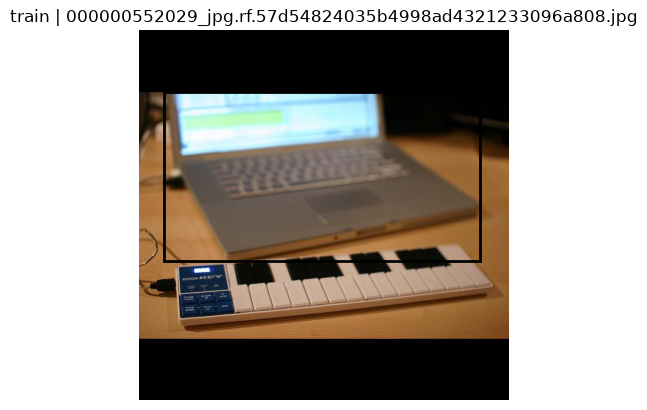

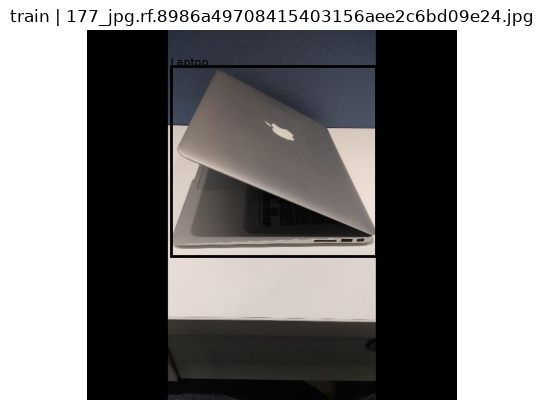

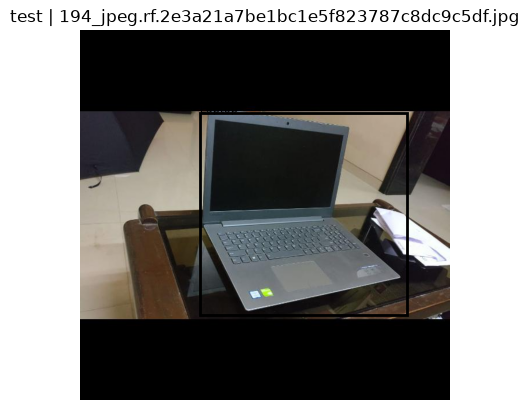

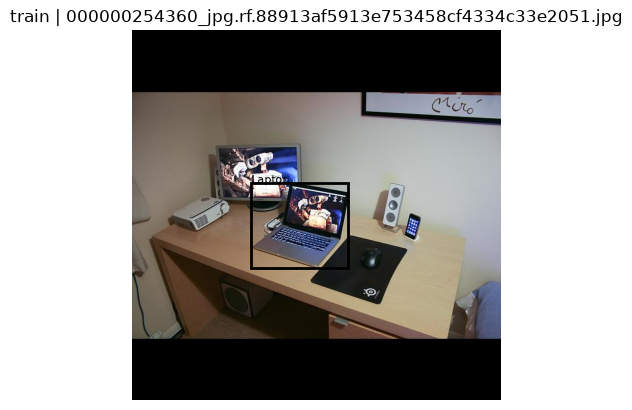

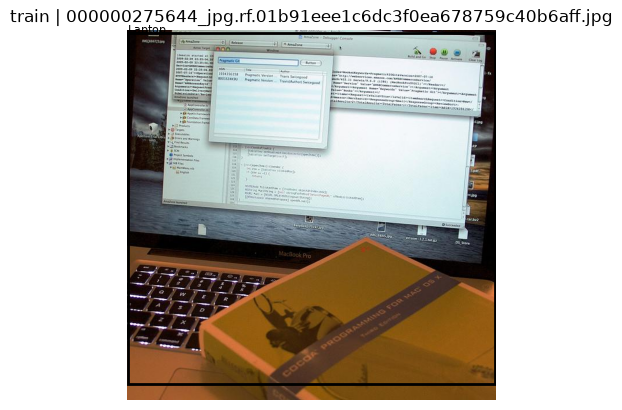

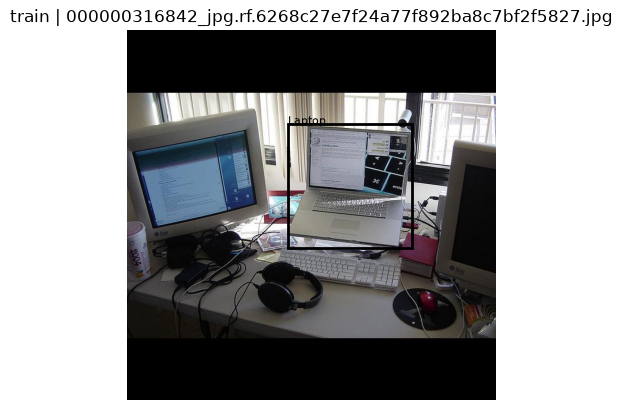

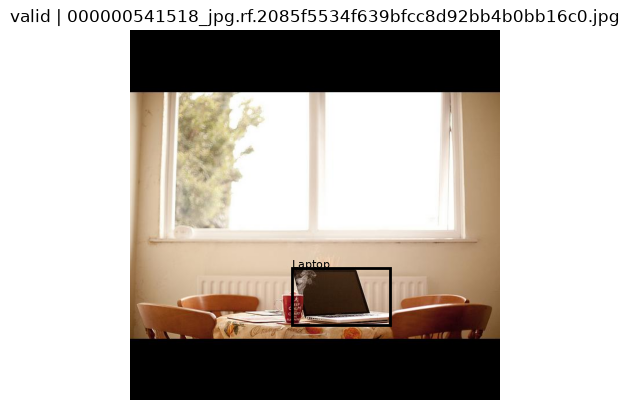

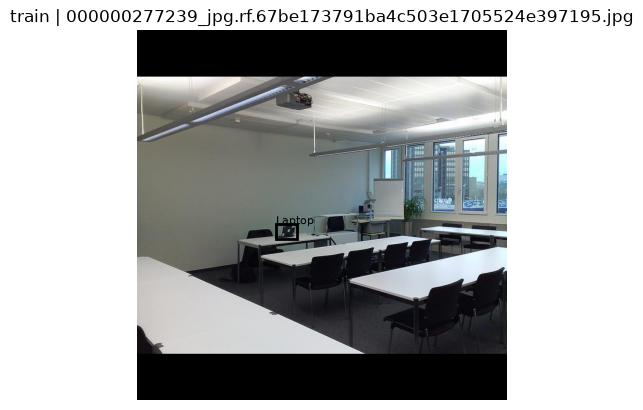

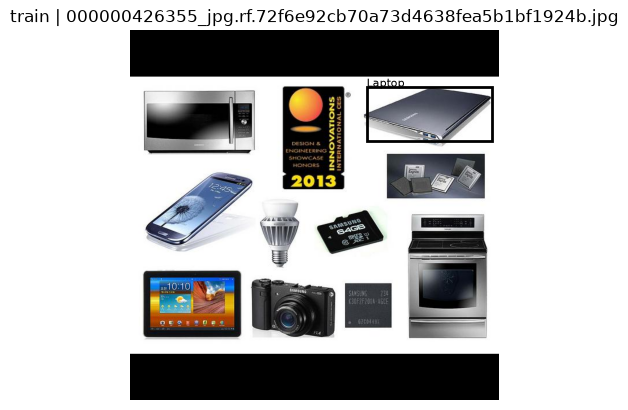

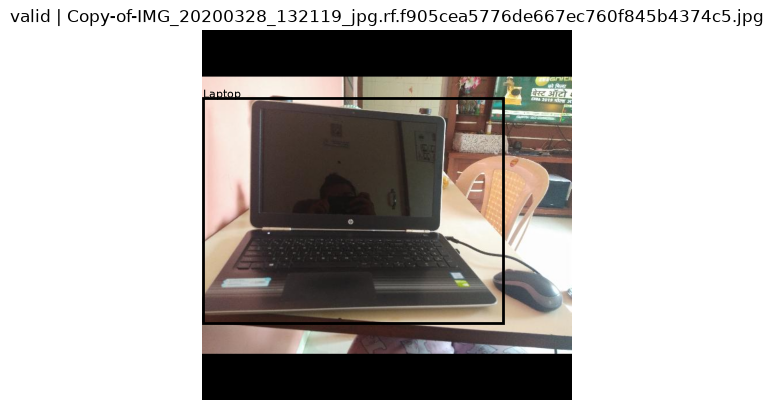

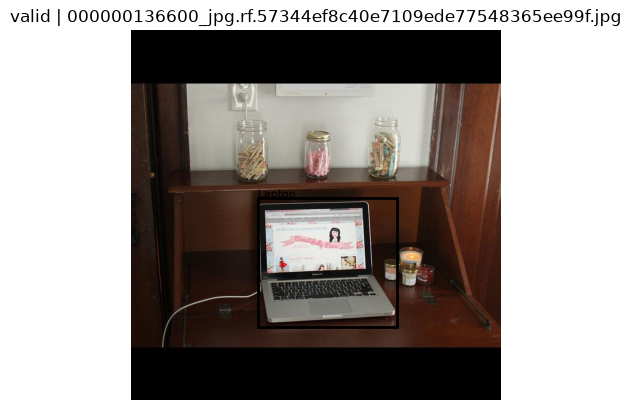

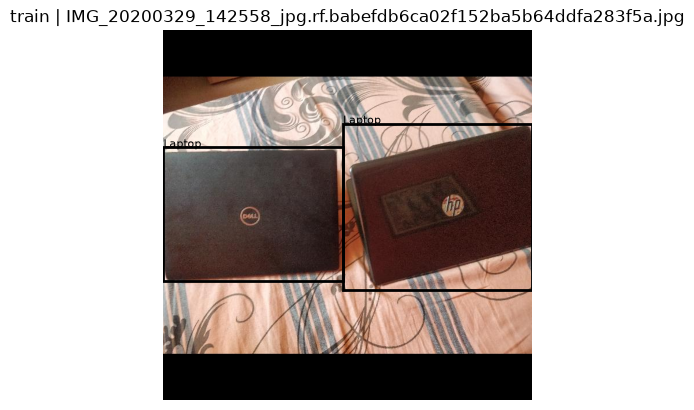

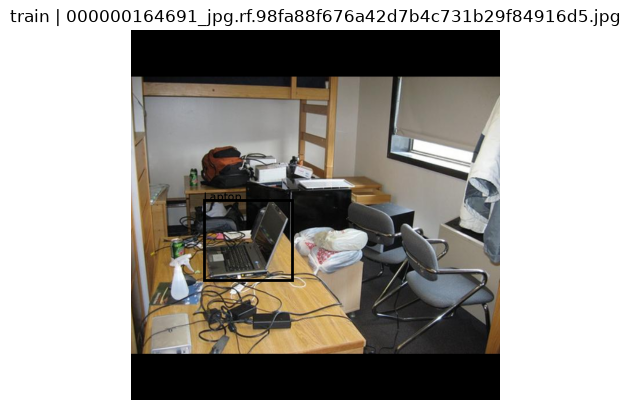

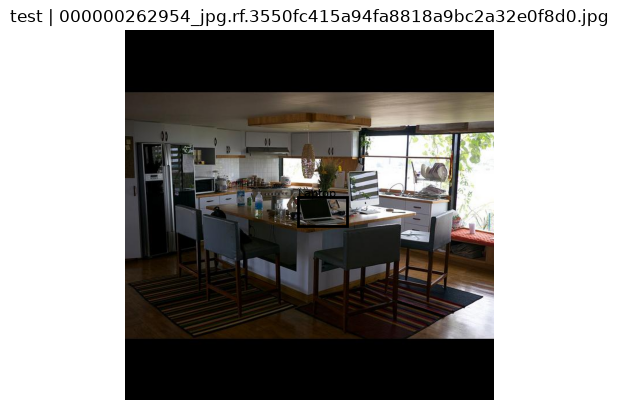

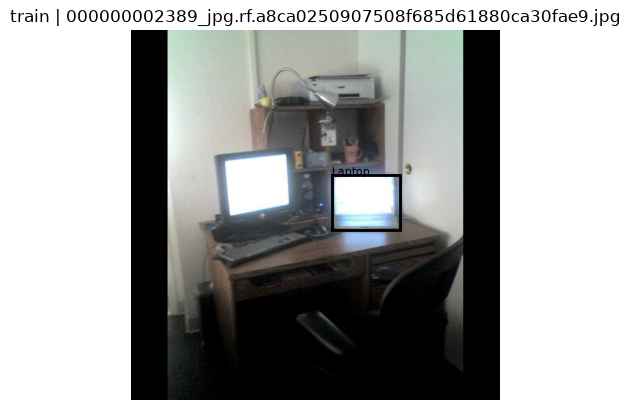

In [23]:
show_random_lt_annotations(15)

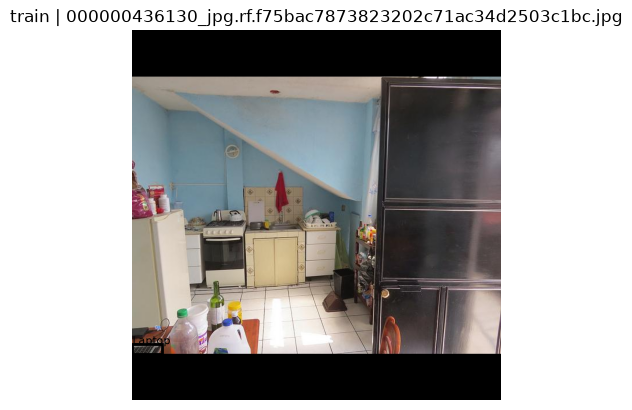

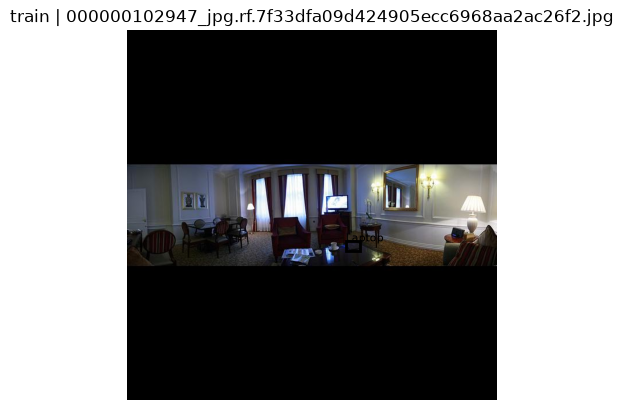

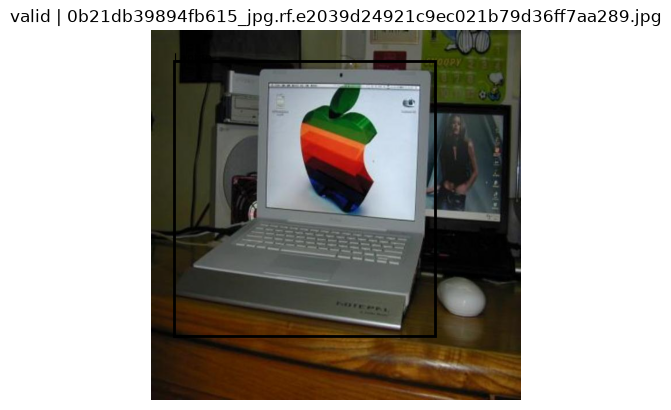

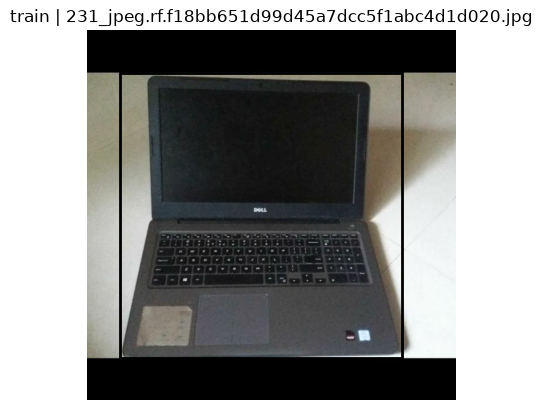

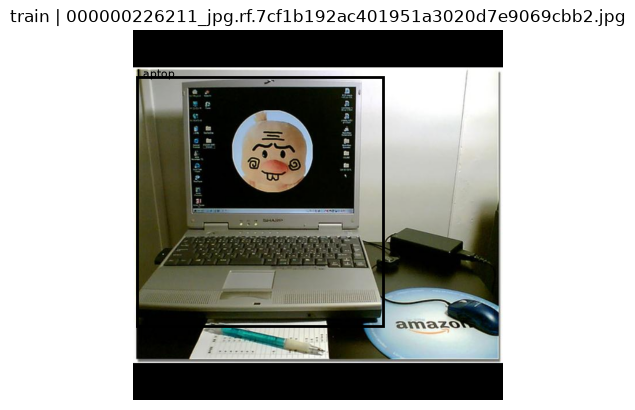

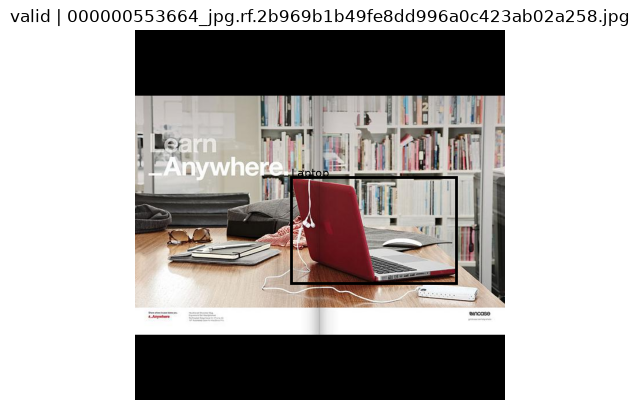

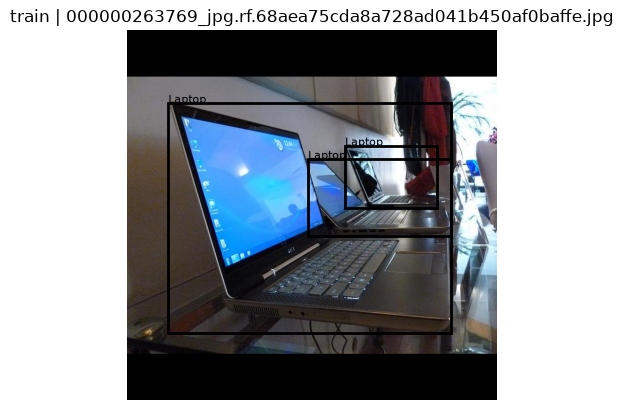

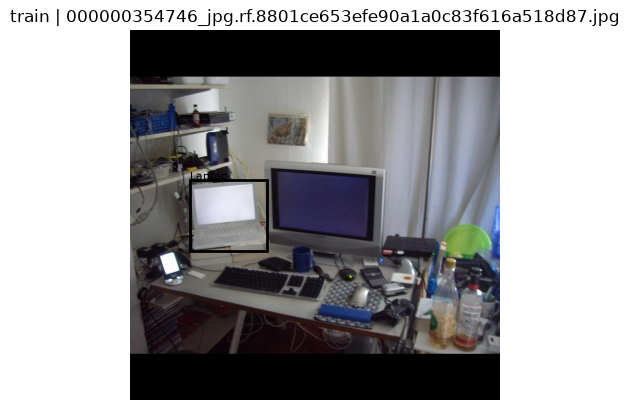

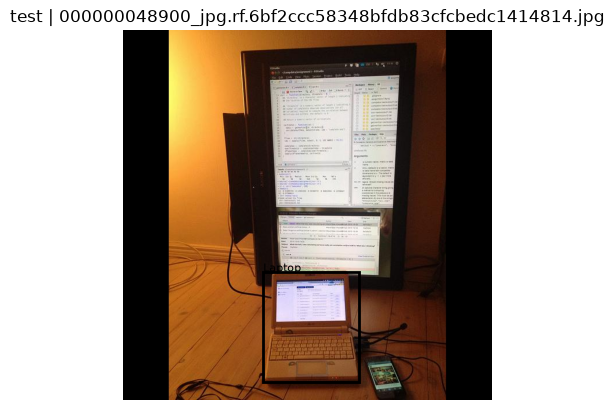

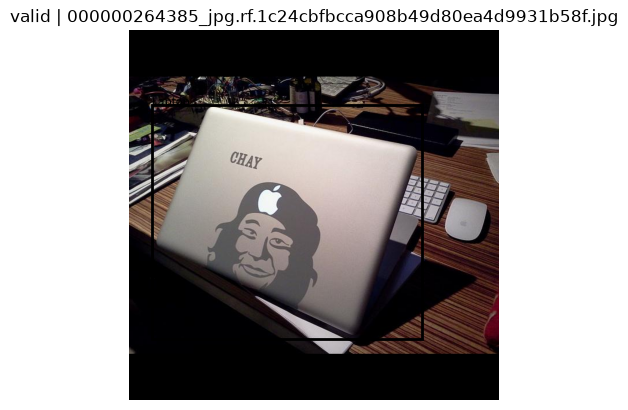

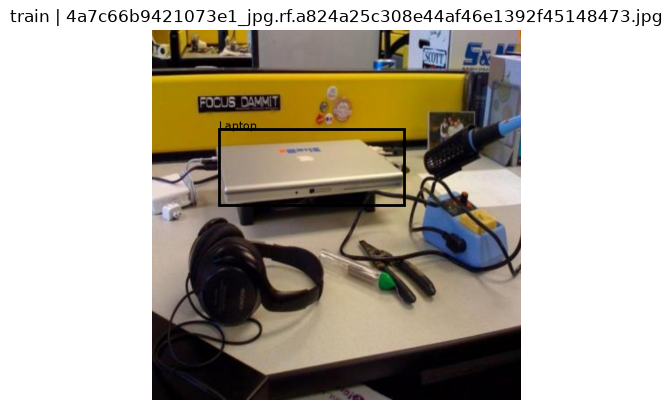

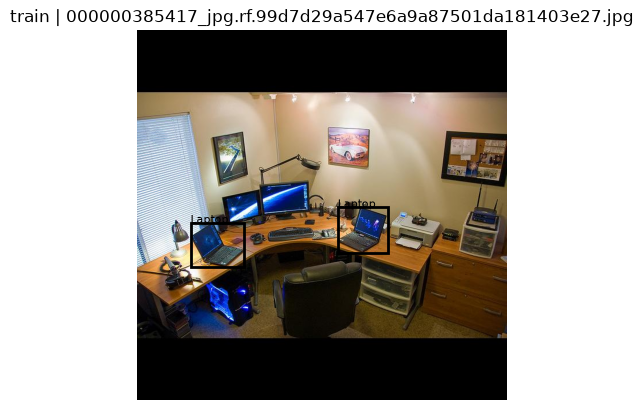

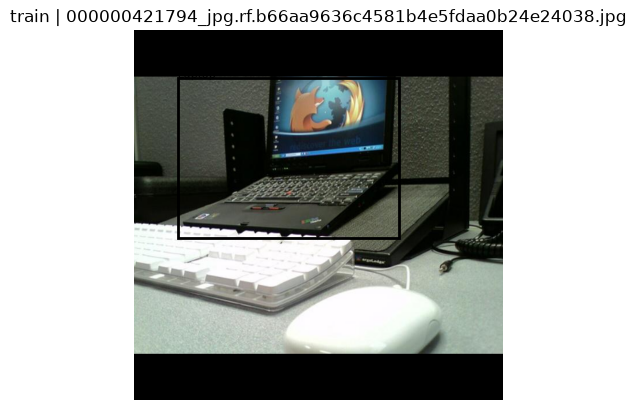

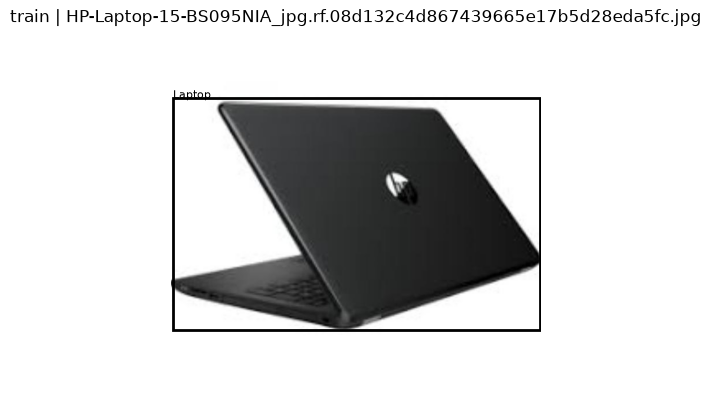

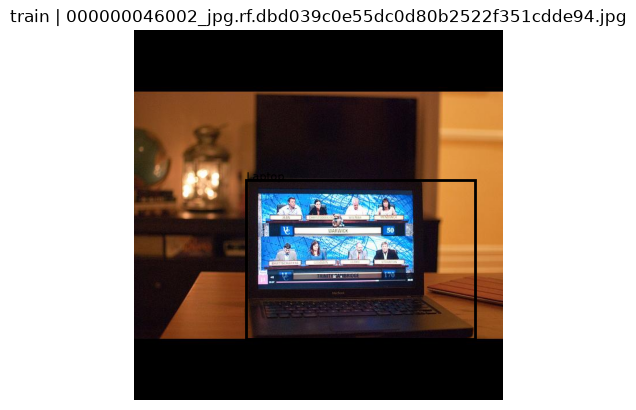

In [24]:
show_random_lt_annotations(15)

In [25]:
thirteen_laptop_images = objects_per_image[
    objects_per_image == 13
]

print(thirteen_laptop_images)

split  image_id  file_name                                               
train  11934     000000188311_jpg.rf.71f0086eacc75298a6925b06491cbc6a.jpg    13
dtype: int64


In [26]:
print(
    "Files belonging to exact duplicate groups:",
    sum(len(group) for group in exact_duplicate_groups)
)

print(
    "Extra exact duplicate copies removable:",
    sum(len(group) - 1 for group in exact_duplicate_groups)
)

Files belonging to exact duplicate groups: 46
Extra exact duplicate copies removable: 23


In [27]:
tablet_images = (
    lt_df[
        lt_df["original_label"] == "Tablet"
    ][
        [
            "split",
            "image_id",
            "file_name"
        ]
    ]
    .drop_duplicates()
)

print(
    "Tablet images:",
    len(tablet_images)
)

Tablet images: 11


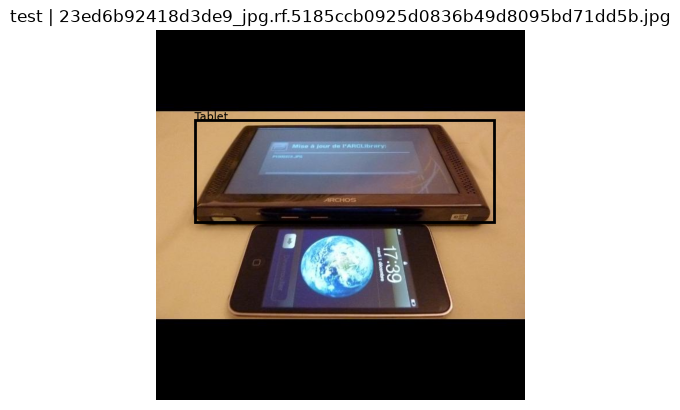

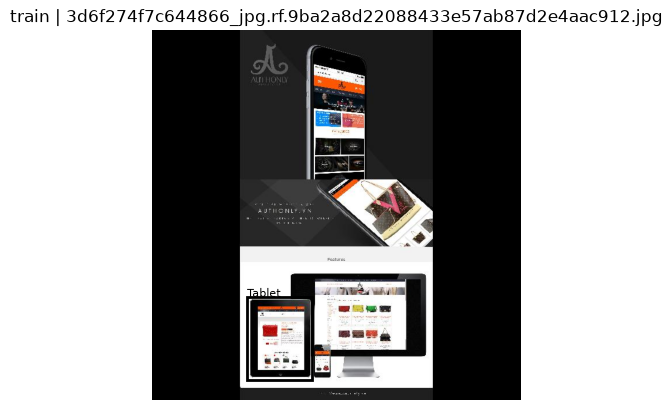

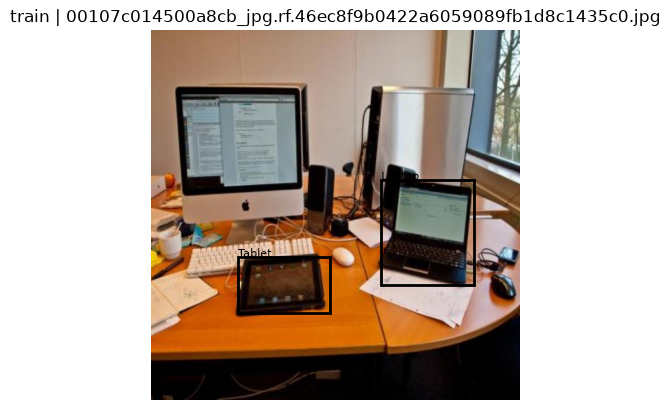

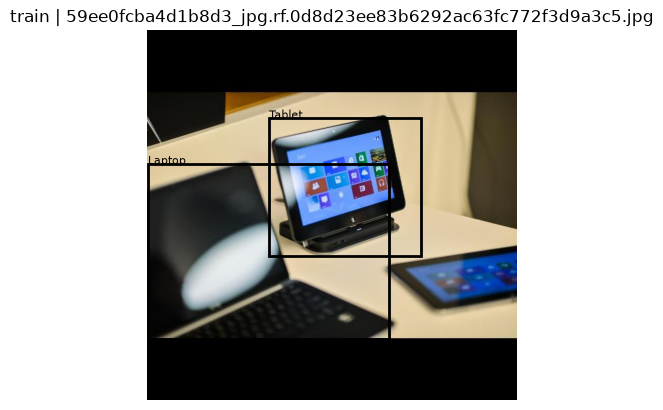

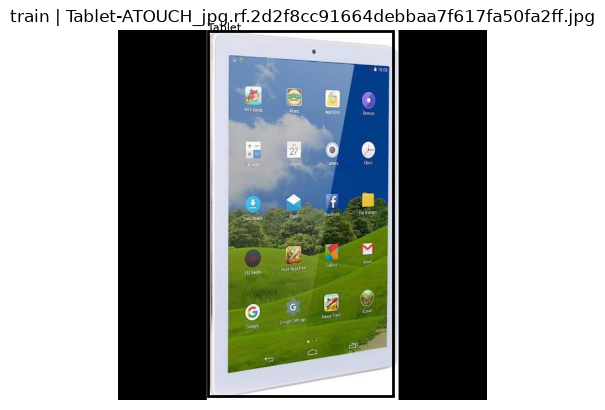

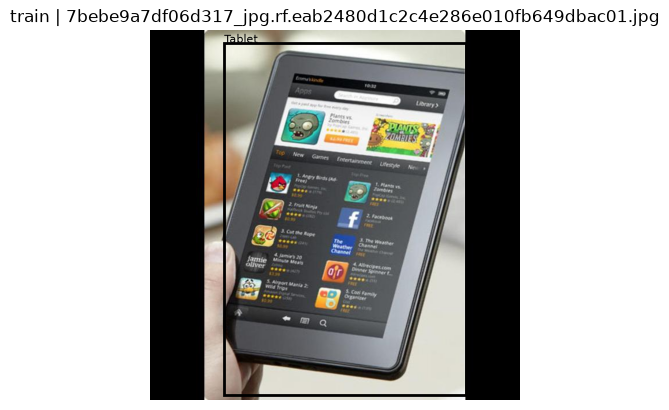

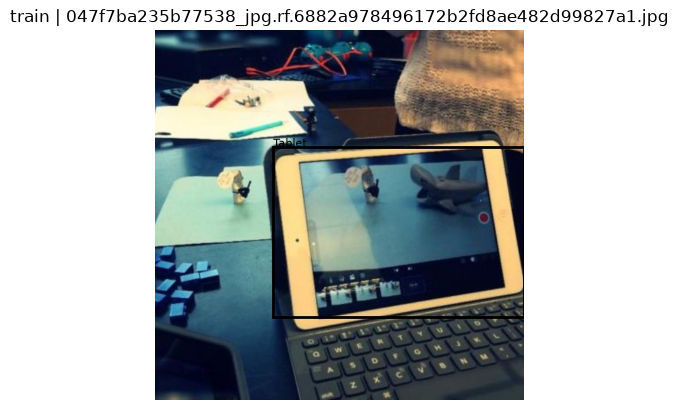

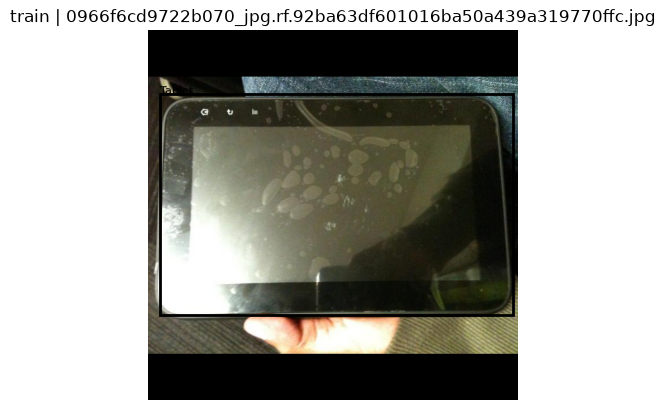

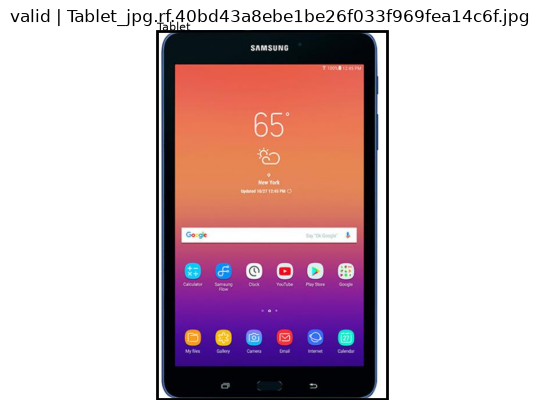

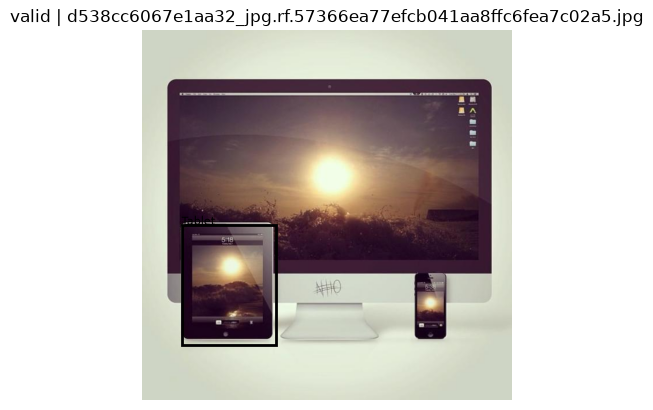

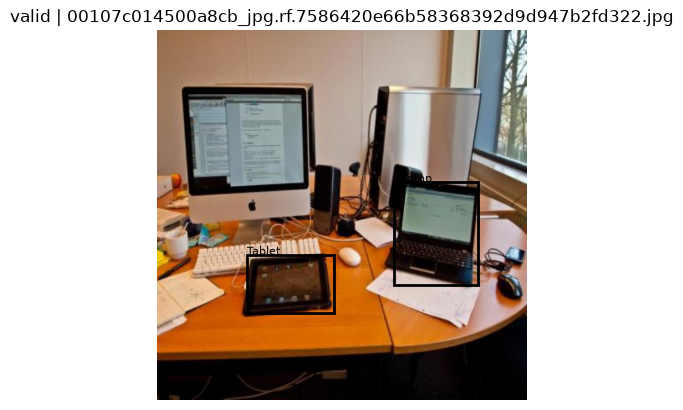

In [28]:
for _, sample in tablet_images.iterrows():

    split = sample["split"]
    image_id = sample["image_id"]
    file_name = sample["file_name"]

    image_path = find_split_image(
        split,
        file_name
    )

    if image_path is None:
        continue

    img = Image.open(image_path)

    fig, ax = plt.subplots()
    ax.imshow(img)

    anns = lt_df[
        (lt_df["split"] == split)
        &
        (lt_df["image_id"] == image_id)
    ]

    for _, ann in anns.iterrows():

        x = ann["bbox_x"]
        y = ann["bbox_y"]
        w = ann["bbox_width"]
        h = ann["bbox_height"]

        rect = patches.Rectangle(
            (x, y),
            w,
            h,
            fill=False,
            linewidth=2
        )

        ax.add_patch(rect)

        ax.text(
            x,
            y,
            ann["original_label"],
            fontsize=8
        )

    ax.set_title(
        f"{split} | {file_name}"
    )

    ax.axis("off")
    plt.show()

Tablet was evaluated but excluded from Dataset A because only 11 annotated images were available, which was insufficient for reliable representation. Tablet support may be added in a future version.

FINAL EDA MARKDOWN

# Final EDA Findings — UNU-KEY E-Waste v44 (Laptop)

## Final Class Selection

The initial inspection considered three UNU-KEY classes:

- Laptop (class ID 39)
- Tablet (class ID 70)
- Power-Adapter (class ID 50)

After EDA, only Laptop will be used from this part of the UNU-KEY dataset.

Final mapping:

Laptop (39) → laptop

The following classes are excluded:

- Tablet (70)
- Power-Adapter (50)
- Desktop-PC

Tablet was excluded because only 11 Tablet images were available. The manually inspected Tablet images were valid and visually distinguishable from smartphones, but 11 examples are insufficient for reliable representation in Dataset A.

Power-Adapter was excluded because its available sample count was too small to meaningfully complete the charger_adapter class. A stronger charger source will be selected separately.

Desktop-PC is intentionally not included in the laptop class because it is visually and physically different from a laptop.

---

## Dataset Format

UNU-KEY is provided in COCO JSON format.

Laptop annotations use:

bbox = [x_min, y_min, width, height]

The COCO bounding boxes were found to correctly identify the Laptop objects in manually inspected samples.

The dataset was previously resized by Roboflow to 640 × 640 using Fit, which introduces black padding in some images.

The original UNU train/validation/test split will NOT be used for final E-Safe training because duplicate/source-group leakage was detected.

---

## Target Counts

Laptop objects:

1502

Distinct images containing Laptop:

1240

During the initial Laptop + Tablet inspection:

- Tablet objects/images: 11
- 3 images contained both Laptop and Tablet
- 1248 distinct images contained Laptop and/or Tablet

Since Tablet has now been excluded, only annotations with original class ID 39 will be retained in the Laptop manifest.

One row in the object-level dataframe represents one Laptop annotation, not one source photograph.

Therefore a single photograph containing several laptops can contribute several Laptop annotations.

One image was found to contain 13 annotated Laptop objects.

This does NOT automatically mean that all 13 will become usable classifier samples. Each individual crop must still pass quality filtering.

---

## Multiple-Laptop Scenes

Several images contain more than one Laptop.

Examples include:

- classrooms containing several laptops
- conference rooms
- desks containing multiple devices
- shared computer areas

These images are considered useful real-world diversity.

During preprocessing, each valid Laptop bounding box may generate one individual classifier crop.

Example:

one classroom image
    → Laptop crop 1
    → Laptop crop 2
    → Laptop crop 3
    → ...

All crops generated from the same source image must remain in the same final train/validation/test split.

Extremely small Laptop annotations from multi-device scenes may be rejected individually even when the original scene itself is valid.

---

## Annotation Quality

Manual inspection showed that Laptop bounding boxes are generally correct.

Most annotations:

- locate the intended Laptop correctly
- contain the complete device when the complete device is visible
- remain useful in cluttered scenes

However, some difficult examples were observed:

- extremely small laptops in large rooms
- partially visible laptops
- severe clipping
- only a small fragment of the keyboard/device visible
- overexposed screens
- highly cluttered surroundings

These samples should not automatically be removed only because they are unusual.

They will be flagged for preprocessing review.

---

## Image and Scene Diversity

The Laptop subset contains strong visual diversity.

Observed backgrounds include:

- classrooms
- offices
- conference rooms
- homes
- bedrooms
- tables
- desks
- product-style photographs
- cluttered workspaces

Observed Laptop variation includes:

- open laptops
- closed laptops
- different brands and designs
- different orientations
- different viewing angles
- multiple laptops in one image
- partially occluded devices
- old/used-looking devices
- cleaner/newer devices

Lighting conditions are also varied.

This diversity is useful because it reduces the risk that the classifier learns one fixed background or photography style instead of Laptop appearance.

---

## Other Objects and Clutter

827 images in the original Laptop + Tablet inspection contained other annotated object classes.

Common scenes contain items such as:

- computer mice
- keyboards
- monitors
- headphones
- phones
- other electronics

This is not automatically a problem.

The provided Laptop bounding boxes allow the final Dataset A pipeline to generate padded Laptop crops and reduce irrelevant scene clutter while retaining useful surrounding context.

---

## Object Size

A substantial number of target annotations are small relative to the complete 640 × 640 image.

During the initial Laptop + Tablet inspection:

- 142 target objects occupied less than 2% of the image
- 399 target objects occupied less than 5% of the image
- 8 target objects occupied more than 80% of the image

Because Tablet is now excluded, these exact counts will be recomputed for Laptop-only during preprocessing.

Manual inspection confirmed that the extreme size ranges contain both valid and unusable examples.

Therefore object-size thresholds will be used for REVIEW, not blind deletion.

Planned review policy:

bbox_area_ratio < 2%
    → mandatory quality review

bbox_area_ratio between 2% and 5%
    → padded crop and review where necessary

bbox_area_ratio > 5%
    → normally retain unless another quality issue exists

bbox_area_ratio > 80%
    → review for severe clipping / fragment-only images

A very small Laptop may still be retained if the cropped image contains enough visual detail to identify it.

A very small Laptop that remains visually ambiguous after cropping will be removed.

A very large close-up will be retained if the Laptop remains recognisable.

A large annotation showing only a severely clipped fragment will be removed.

---

## Duplicate and Source-Group Findings

During the initial Laptop + Tablet inspection:

- 27 repeated source groups were detected
- 28 additional related/repeated image files were identified through source grouping
- 23 exact duplicate groups were detected
- 46 files belonged to exact duplicate groups
- 23 exact duplicate copies are removable
- 14 source groups appeared across more than one provided train/validation/test split

This confirms that the original UNU split cannot be trusted for final E-Safe evaluation.

Exact duplicate copies will be removed before final Dataset A splitting.

Related images that are not exact duplicates may still be retained if they add useful visual information, but they must remain in the same final group/split.

After Tablet is excluded, duplicate statistics will be recalculated on the Laptop-only subset during final preprocessing.

---

## Dataset Integrity

The UNU dataset uses valid COCO annotations and the Laptop bounding boxes inspected manually were generally aligned correctly.

The previously performed UNU checks showed:

- consistent 640 × 640 exported images
- no major image/annotation mapping problem
- valid COCO bounding boxes
- substantial real-world background diversity

Raw UNU files will remain completely unchanged.

---

## Main Strengths

The UNU Laptop source provides:

- more than 1,200 distinct Laptop-containing images
- more than 1,500 Laptop annotations
- varied backgrounds
- varied lighting
- open and closed laptops
- multiple-device scenes
- realistic rooms and workspaces
- varied device scale
- useful bounding-box annotations

The dataset provides enough volume that aggressive removal of obviously unusable examples can be performed without needing another Laptop dataset.

---

## Main Limitations

The main limitations are:

- exact duplicate images
- related source-image groups
- leakage across the provided splits
- many very small Laptop instances
- some severely clipped Laptop instances
- some scene-level clutter
- black borders introduced by Roboflow Fit resizing

All of these limitations are considered manageable during preprocessing.

---

## Final Decision

UNU-KEY E-Waste v44 will be retained as the source for the E-Safe:

laptop

class.

Laptop data collection is considered COMPLETE.

No additional Laptop dataset will be collected at this stage.

Tablet will not be supported in the current Dataset A MVP because only 11 Tablet examples were available.

Tablet support may be added as a future extension if sufficient data becomes available.

Power-Adapter from UNU will also not be used.

The raw UNU dataset will remain untouched, and all filtering, deduplication, cropping and splitting will occur later in the Dataset A cleaning pipeline.

CREATE THE FINAL UNU LAPTOP MANIFEST

In [29]:
laptop_df = lt_df[
    lt_df["original_class_id"] == 39
].copy()

print("Laptop annotation rows:", len(laptop_df))

print(
    "Distinct Laptop images:",
    laptop_df[
        ["split", "image_id"]
    ].drop_duplicates().shape[0]
)

Laptop annotation rows: 1502
Distinct Laptop images: 1240


Build hashes for Laptop images

In [30]:
import hashlib

laptop_images = (
    laptop_df[
        [
            "split",
            "image_id",
            "file_name"
        ]
    ]
    .drop_duplicates()
)

image_md5 = {}


for _, row in laptop_images.iterrows():

    image_path = find_split_image(
        row["split"],
        row["file_name"]
    )

    if image_path is None:
        continue

    with open(image_path, "rb") as f:

        image_md5[
            (
                row["split"],
                row["image_id"]
            )
        ] = hashlib.md5(
            f.read()
        ).hexdigest()

Count Laptop annotations per source image

In [31]:
laptops_per_image = (
    laptop_df
    .groupby(
        [
            "split",
            "image_id"
        ]
    )
    .size()
)

Build exact-duplicate group information

In [32]:
from collections import defaultdict

hash_groups = defaultdict(list)

for key, md5_hash in image_md5.items():

    hash_groups[
        md5_hash
    ].append(key)


duplicate_hashes = {
    md5_hash
    for md5_hash, files
    in hash_groups.items()
    if len(files) > 1
}

Find Laptop source groups leaking across supplied splits

In [33]:
laptop_group_splits = (
    laptop_df[
        [
            "source_group_id",
            "split"
        ]
    ]
    .drop_duplicates()
    .groupby(
        "source_group_id"
    )["split"]
    .agg(
        lambda x:
        sorted(set(x))
    )
)


laptop_cross_split_groups = (
    laptop_group_splits[
        laptop_group_splits.apply(len) > 1
    ]
)


cross_split_ids = set(
    laptop_cross_split_groups.index
)


print(
    "Laptop source groups appearing across splits:",
    len(laptop_cross_split_groups)
)

Laptop source groups appearing across splits: 14


Create manifest

In [34]:
manifest_df = laptop_df.copy()


manifest_df.rename(
    columns={
        "split":
            "original_split"
    },
    inplace=True
)


manifest_df.insert(
    0,
    "sample_id",
    [
        f"UNUL{i:05d}"
        for i in range(
            1,
            len(manifest_df) + 1
        )
    ]
)


manifest_df.insert(
    1,
    "source_dataset",
    "UNU-KEY E-Waste Dataset v44"
)


manifest_df.insert(
    2,
    "license",
    "CC BY 4.0"
)

Add hash:

In [35]:
manifest_df[
    "image_md5"
] = manifest_df.apply(

    lambda row:
        image_md5.get(
            (
                row["original_split"],
                row["image_id"]
            )
        ),

    axis=1
)

Add number of laptops in source image:

In [36]:
manifest_df[
    "laptop_count_in_image"
] = manifest_df.apply(

    lambda row:
        laptops_per_image.loc[
            (
                row["original_split"],
                row["image_id"]
            )
        ],

    axis=1
)

Add exact duplicate flags

In [37]:
manifest_df[
    "exact_duplicate_member"
] = manifest_df[
    "image_md5"
].isin(
    duplicate_hashes
)

Add cross-split group flag

In [38]:
manifest_df[
    "source_group_cross_split"
] = manifest_df[
    "source_group_id"
].isin(
    cross_split_ids
)

Add crop coordinates

In [39]:
manifest_df[
    "bbox_xmin"
] = manifest_df[
    "bbox_x"
]


manifest_df[
    "bbox_ymin"
] = manifest_df[
    "bbox_y"
]


manifest_df[
    "bbox_xmax"
] = (
    manifest_df[
        "bbox_x"
    ]
    +
    manifest_df[
        "bbox_width"
    ]
)


manifest_df[
    "bbox_ymax"
] = (
    manifest_df[
        "bbox_y"
    ]
    +
    manifest_df[
        "bbox_height"
    ]
)

Add quality-review flags

In [40]:
manifest_df[
    "tiny_object_flag"
] = (
    manifest_df[
        "bbox_area_ratio"
    ] < 0.02
)


manifest_df[
    "small_object_flag"
] = (
    (
        manifest_df[
            "bbox_area_ratio"
        ] >= 0.02
    )
    &
    (
        manifest_df[
            "bbox_area_ratio"
        ] < 0.05
    )
)


manifest_df[
    "very_large_object_flag"
] = (
    manifest_df[
        "bbox_area_ratio"
    ] > 0.80
)


manifest_df[
    "multi_laptop_image"
] = (
    manifest_df[
        "laptop_count_in_image"
    ] > 1
)

Initial preprocessing status

In [41]:
manifest_df[
    "preprocessing_status"
] = "pending"

In [42]:
review_mask = (

    manifest_df[
        "tiny_object_flag"
    ]

    |

    manifest_df[
        "very_large_object_flag"
    ]

    |

    manifest_df[
        "exact_duplicate_member"
    ]

    |

    manifest_df[
        "source_group_cross_split"
    ]
)


manifest_df.loc[
    review_mask,
    "preprocessing_status"
] = "review"

Add notes field

In [43]:
manifest_df[
    "review_note"
] = ""

This is useful later for things such as:

tiny but usable
severely clipped
duplicate remove
bad annotation
keep close-up

In [44]:
print(
    "Manifest rows:",
    len(manifest_df)
)

print(
    "\nStatus:"
)

print(
    manifest_df[
        "preprocessing_status"
    ].value_counts()
)


print(
    "\nTiny:"
)

print(
    manifest_df[
        "tiny_object_flag"
    ].value_counts()
)


print(
    "\nVery large:"
)

print(
    manifest_df[
        "very_large_object_flag"
    ].value_counts()
)


manifest_df.head()

Manifest rows: 1502

Status:
preprocessing_status
pending    1286
review      216
Name: count, dtype: int64

Tiny:
tiny_object_flag
False    1360
True      142
Name: count, dtype: int64

Very large:
very_large_object_flag
False    1494
True        8
Name: count, dtype: int64


,sample_id,source_dataset,license,original_split,annotation_id,image_id,file_name,source_group_id,original_class_id,original_label,...,bbox_xmin,bbox_ymin,bbox_xmax,bbox_ymax,tiny_object_flag,small_object_flag,very_large_object_flag,multi_laptop_image,preprocessing_status,review_note
0,UNUL00001,UNU-KEY E-Waste Dataset v44,CC BY 4.0,test,4,4,000000381160_jpg.rf.028674326684d50439af3b74c0...,000000381160,39,Laptop,...,2,109,638.582,397.371,False,False,False,False,pending,
1,UNUL00002,UNU-KEY E-Waste Dataset v44,CC BY 4.0,test,26,21,000000096757_jpg.rf.01febdaa039cb520c6df36840a...,000000096757,39,Laptop,...,297,261,639.400,552.460,False,False,False,True,pending,
2,UNUL00003,UNU-KEY E-Waste Dataset v44,CC BY 4.0,test,27,21,000000096757_jpg.rf.01febdaa039cb520c6df36840a...,000000096757,39,Laptop,...,159,350,354.430,406.920,False,True,False,True,pending,
3,UNUL00004,UNU-KEY E-Waste Dataset v44,CC BY 4.0,test,31,23,000000249111_jpg.rf.025f6cd960d3f718fe7767953b...,000000249111,39,Laptop,...,86,48,551.971,447.821,False,False,False,False,pending,
4,UNUL00005,UNU-KEY E-Waste Dataset v44,CC BY 4.0,test,87,41,000000518080_jpg.rf.04393a45d8424902800a1a72f7...,000000518080,39,Laptop,...,234,379,446.850,609.110,False,False,False,False,pending,


In [45]:
output_path = (
    "../../data/metadata/"
    "unu_laptop_manifest.csv"
)


manifest_df.to_csv(
    output_path,
    index=False
)


print(
    "Saved:",
    output_path
)

Saved: ../../data/metadata/unu_laptop_manifest.csv


In [46]:
pd.read_csv(
    output_path
).head()

,sample_id,source_dataset,license,original_split,annotation_id,image_id,file_name,source_group_id,original_class_id,original_label,...,bbox_xmin,bbox_ymin,bbox_xmax,bbox_ymax,tiny_object_flag,small_object_flag,very_large_object_flag,multi_laptop_image,preprocessing_status,review_note
0,UNUL00001,UNU-KEY E-Waste Dataset v44,CC BY 4.0,test,4,4,000000381160_jpg.rf.028674326684d50439af3b74c0...,000000381160,39,Laptop,...,2,109,638.582,397.371,False,False,False,False,pending,NaN
1,UNUL00002,UNU-KEY E-Waste Dataset v44,CC BY 4.0,test,26,21,000000096757_jpg.rf.01febdaa039cb520c6df36840a...,000000096757,39,Laptop,...,297,261,639.400,552.460,False,False,False,True,pending,NaN
2,UNUL00003,UNU-KEY E-Waste Dataset v44,CC BY 4.0,test,27,21,000000096757_jpg.rf.01febdaa039cb520c6df36840a...,000000096757,39,Laptop,...,159,350,354.430,406.920,False,True,False,True,pending,NaN
3,UNUL00004,UNU-KEY E-Waste Dataset v44,CC BY 4.0,test,31,23,000000249111_jpg.rf.025f6cd960d3f718fe7767953b...,000000249111,39,Laptop,...,86,48,551.971,447.821,False,False,False,False,pending,NaN
4,UNUL00005,UNU-KEY E-Waste Dataset v44,CC BY 4.0,test,87,41,000000518080_jpg.rf.04393a45d8424902800a1a72f7...,000000518080,39,Laptop,...,234,379,446.850,609.110,False,False,False,False,pending,NaN


FINAL LAPTOP-ONLY SUMMARY CELL

In [47]:
print("===== FINAL UNU LAPTOP SUMMARY =====")

print(
    "Laptop objects:",
    len(laptop_df)
)

print(
    "Distinct Laptop images:",
    laptop_df[
        ["split", "image_id"]
    ].drop_duplicates().shape[0]
)

print(
    "Unique source groups:",
    laptop_df[
        "source_group_id"
    ].nunique()
)

print(
    "Laptop source groups across original splits:",
    len(
        laptop_cross_split_groups
    )
)

print(
    "Exact duplicate image hashes:",
    len(
        duplicate_hashes
    )
)

print(
    "Objects <2%:",
    (
        laptop_df[
            "bbox_area_ratio"
        ] < 0.02
    ).sum()
)

print(
    "Objects 2–5%:",
    (
        (
            laptop_df[
                "bbox_area_ratio"
            ] >= 0.02
        )
        &
        (
            laptop_df[
                "bbox_area_ratio"
            ] < 0.05
        )
    ).sum()
)

print(
    "Objects >80%:",
    (
        laptop_df[
            "bbox_area_ratio"
        ] > 0.80
    ).sum()
)

print(
    "Average bbox area:",
    laptop_df[
        "bbox_area_ratio"
    ].mean()
)

print(
    "Median bbox area:",
    laptop_df[
        "bbox_area_ratio"
    ].median()
)

print(
    "Minimum bbox area:",
    laptop_df[
        "bbox_area_ratio"
    ].min()
)

print(
    "Maximum bbox area:",
    laptop_df[
        "bbox_area_ratio"
    ].max()
)

===== FINAL UNU LAPTOP SUMMARY =====
Laptop objects: 1502
Distinct Laptop images: 1240
Unique source groups: 1212
Laptop source groups across original splits: 14
Exact duplicate image hashes: 23
Objects <2%: 142
Objects 2–5%: 254
Objects >80%: 8
Average bbox area: 0.19734225482881387
Median bbox area: 0.12794137569213865
Minimum bbox area: 0.0002543701171875
Maximum bbox area: 0.9645184516601563
